# Explanatory Data Analysis

Your first task is to explore the dataset you’ve been assigned. It’s your responsibility to complete all the to-do steps and generate the following:

- Identify the `type of dataset`
- Print the `list of building IDs`
- Select 3 random building IDs, and for a year within its available data range, determine and print the following: 1) `Start date` 2) `End date` 3) `Latitude` 4) `Longitude` 5) `Building type` 6) `Plot the data from day 1 for the selected buildings`

__Important__: For this exercise, start by scrolling to the last cell and completing the first three `TODO` tasks. When you need to update the `plot_load` function, go to the cell above, make the necessary changes, and then return to the last cell to continue.`

__TIP__: Please refer to the table below to view the data ranges and example building IDs for each dataset.

```
| Dataset    | Data Range  | Example ID     |
|------------|-------------|----------------|
| Ideal      | 2017–2018   | home241        |
| Electricity| 2012–2014   | MT_061         |
| lcl        | 2012–2013   | MAC003538      |
| sceaux     | 2007–2010   | Sceaux         |
| borealis   | 2011        | home25         |
```

Below is a screenshot of the output I generated. Your output should look similar. Feel free to modify the plot or adjust other features for your convenience, but only make changes where you see `# TODO:`. Do not edit any other sections of the code.

![NN model architecture](../../Images/EDA.png)

In [5]:
# ------------------- #
# --- Do Not Edit --- #
# ------------------- #

import os
from pathlib import Path
from buildings_bench import load_torch_dataset
from buildings_bench.transforms import TimestampTransform
import matplotlib.pyplot as plt
import numpy as np

os.environ["BUILDINGS_BENCH"] = "/global/cfs/cdirs/m4388/Project4/Dataset"

class EDA:
    def __init__(self, dataset_name, dataset):
        self.name = dataset_name
        self.datasets = dataset.building_datasets

    @staticmethod
    def reconstruct_datetime(data, year):
        timestamp = np.concatenate([
            data['day_of_year'],
            data['day_of_week'],
            data['hour_of_day']
        ], axis=-1)

        timestamp = TimestampTransform().undo_transform(timestamp)

        dt = (
            np.datetime64(f'{year}-01-01')
            + np.timedelta64(1, 'D') * (timestamp[..., 0] - 1)
            + np.timedelta64(1, 'h') * timestamp[..., -1]
        )

        return dt, timestamp

    def dataset_summary(self):
        print(f"Dataset: {self.name}")
        print(f"Type: {type(self.datasets)}")
        print(f"Building IDs: {list(self.datasets.keys())}")

    def building_summary(self, building_id, year):
        ds = dict(self.datasets[building_id])

        data_start = ds[year][0]
        data_end = ds[year][len(ds[year])]

        dt_start, _ = self.reconstruct_datetime(data_start, year)
        dt_end, _ = self.reconstruct_datetime(data_end, year)

        lat = float(data_start['latitude'][0][0])
        lon = float(data_start['longitude'][0][0])
        btype = int(data_start['building_type'][0][0])

        print(f"Building ID: {building_id}")
        print(f"Year: {year}")
        print(f"Number of records in {building_id}: {len(ds[year])}")
        print(f"Start date: {dt_start[0]}")
        print(f"End date: {dt_end[-1]}")
        print(f"Latitude: {lat:.4f}")
        print(f"Longitude: {lon:.4f}")
        print(f"Building Type: {btype}")

    def plot_load(self, building_id, year, day):
        ds = dict(self.datasets[building_id])

        if day < 0 or day >= len(ds[year]):
            print(f"Invalid day index: {day}. Valid range is 0 to {len(ds[year])-1}.")
            return

        data = ds[year][day]
        dt, _ = self.reconstruct_datetime(data, year)
        load = data['load'].squeeze()

        lat = float(data['latitude'][0][0])
        lon = float(data['longitude'][0][0])
        btype = int(data['building_type'][0][0])

# ------------------- #
# --- Do Not Edit --- #
# ------------------- #   

# ------------------- #
# ------ EDIT ------- #
# ------------------- # 
        
        plt.figure(figsize=(12, 4))
        # Plot load values against datetime **(converted to minute-level resolution)**
        plt.plot(dt, load, color='blue', linewidth=1)
        # Set x-axis label to 'Datetime'
        plt.xlabel('Datetime', fontsize=16)
        # Set y-axis label to 'Load (kW)'
        plt.ylabel('Load (kW)', fontsize=16)
        # Set the plot title with building ID, year, day index, latitude, longitude, and building type
        plt.title(f'{building_id} | {year} Day Index {day} | Lat: {lat}, Lon: {lon}, Type: {btype}')
        # Rotate x-axis tick labels for better readability
        plt.xticks(rotation=45)
        # Apply tight layout to prevent label cutoff
        plt.tight_layout()
        # Display a grid to improve visual clarity
        plt.grid(True)
        plt.show()
        
# ------------------- #
# ------ EDIT ------- #
# ------------------- #

Dataset: borealis
Type: <class 'dict'>
Building IDs: ['home25', 'home2', 'home22', 'home14', 'home19', 'home4', 'home9', 'home23', 'home16', 'home15', 'home21', 'home26', 'home7', 'home18', 'home3']
Building ID: home2
Year: 2011
Number of records in home2: 265
Start date: 2011-01-01T00
End date: 2011-09-30T23
Latitude: 1.5620
Longitude: 1.9639
Building Type: 0
Building ID: home14
Year: 2011
Number of records in home14: 223
Start date: 2011-03-27T15
End date: 2011-11-13T14
Latitude: 1.5620
Longitude: 1.9639
Building Type: 0
Building ID: home25
Year: 2011
Number of records in home25: 213
Start date: 2011-04-06T17
End date: 2011-11-13T16
Latitude: 1.5620
Longitude: 1.9639
Building Type: 0


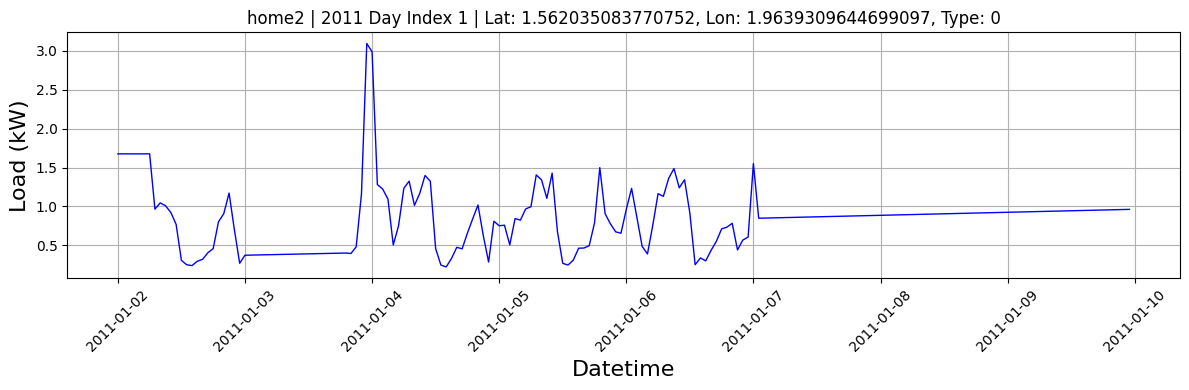

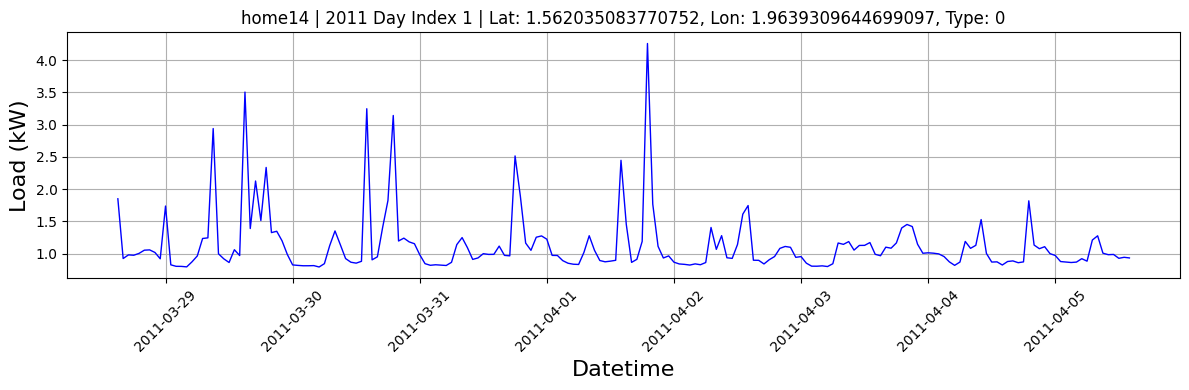

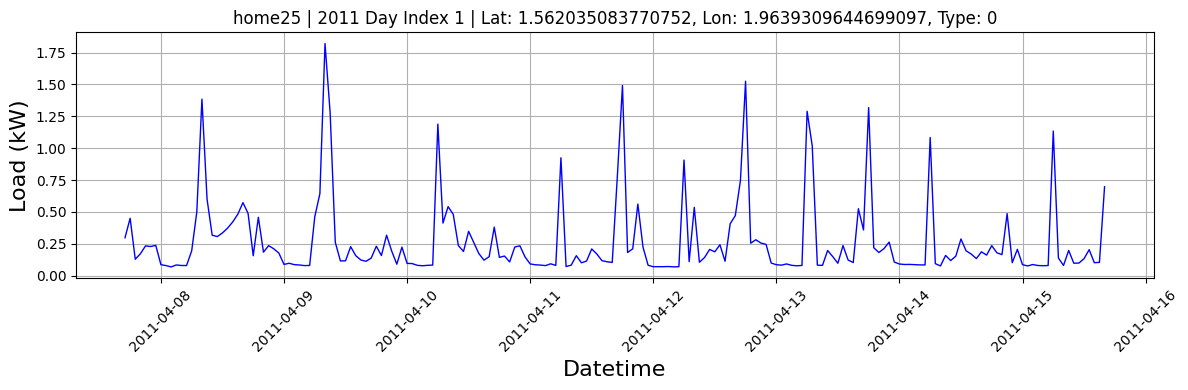

In [6]:
# ------------------- #
# ------ EDIT ------- #
# ------------------- #

if __name__ == "__main__":
    dataset_name = 'borealis'
    dataset = load_torch_dataset(dataset_name, apply_scaler_transform='')
    
    # Instantiate the EDA class
    myEDA = EDA(dataset_name, dataset)
    
    # Run dataset_summary method
    myEDA.dataset_summary()
    
    # Select 3 random building_ids and then run the building_summary method with appropriate data
    # 2, 10, 25

    myEDA.building_summary('home2', 2011)
    myEDA.building_summary('home14', 2011)
    myEDA.building_summary('home25', 2011)
    
    # Update the plot_load function to include code for plotting data
    # Call the plot_load function and plot for day 1

    myEDA.plot_load('home2', 2011, 1)
    myEDA.plot_load('home14', 2011, 1)
    myEDA.plot_load('home25', 2011, 1)

# ------------------- #
# ------ EDIT ------- #
# ------------------- #

## Next Step:

`/BuildingsBenchTutorial/Tutorials/Final-Project-Modules/Train-Model.ipynb`